**Сначала переключитесь на графический процессор!**

# 6. Практическое занятие. Свёрточные нейронные сети (CNN)

**Цель работы:** Познакомиться с архитектурой CNN, научиться строить и обучать свёрточные сети для классификации изображений, визуализировать карты активации и экспериментировать с архитектурными решениями.

В этой практике мы будем использовать датасет CIFAR-10 (32x32 цветных изображения, 10 классов).

## 0. Импорты и подготовка данных

Импортируем необходимые библиотеки и загружаем CIFAR-10.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import time

# Для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA runtime in torch: {torch.version.cuda}')
    torch.backends.cudnn.benchmark = True

Using device: cuda
GPU: Tesla T4
CUDA runtime in torch: 12.8


In [ ]:
# Загрузка данных CIFAR-10
# Для ускорения возьмём подвыборку (первые 10000 обучающих, 2000 тестовых)
# Но можно и полный датасет, если есть время.

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

train_full = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_full = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

# Для экспериментов возьмём подвыборку (ускорит обучение)
num_train = 10000
num_val = 2000
indices = torch.randperm(len(train_full))
train_indices = indices[:num_train]
val_indices = indices[num_train:num_train+num_val]

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(train_full, val_indices)
test_dataset = test_full

print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')

  0%|          | 131k/170M [00:01<36:41, 77.4kB/s]


KeyboardInterrupt: 

In [ ]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f'Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}')

Train size: 10000, Val size: 2000, Test size: 10000


## 1. Построение базовой CNN (10 мин)

Определим класс `SimpleCNN` с двумя свёрточными слоями, пулингом и полносвязными слоями.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  # 32x32 -> 32x32
        self.pool = nn.MaxPool2d(2)                               # 32x32 -> 16x16
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 16x16 -> 16x16
        # После второго пулинга: 64 канала * 8 * 8
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # x - входное изображение.
        x = self.pool(F.relu(self.conv1(x)))
        # теперь x - 32 карты признаков размером 16x16
        x = self.pool(F.relu(self.conv2(x)))
        # теперь x - 64 карты признаков размером 8x8

        # растягиваем тензор 64х8х8 в один большой вектор.
        x = x.view(x.size(0), -1)  # flatten

        x = self.dropout(F.relu(self.fc1(x)))
        # теперь х - вектор из 256 результатов активации нейронов
        x = self.fc2(x)
        # теперь х - вектор из 10 чисел, имеющих значения (-inf; inf).
        # Т.к. ниже написан выбор кросс-энтропии в качестве функции потерь
        # для многоклассовой классификации
        # criterion = nn.CrossEntropyLoss()
        # то к х после завершения данного метода
        # ещё дополнительно применится функция softmaх,
        # которая отмасштабирует значения х до отрезка [0; 1]
        return x

model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Посчитаем количество параметров
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Количество обучаемых параметров: {count_parameters(model)}')

Количество обучаемых параметров: 1070794


## 2. Обучение и базовая оценка

Напишем функцию для одной эпохи обучения и оценки. Обучим модель на 5 эпохах и сохраним историю потерь.

Epoch 1/5, Train Loss: 1.7908, Val Loss: 1.4777, Val Acc: 0.4705
Epoch 2/5, Train Loss: 1.4427, Val Loss: 1.3632, Val Acc: 0.4915
Epoch 3/5, Train Loss: 1.2943, Val Loss: 1.2752, Val Acc: 0.5485
Epoch 4/5, Train Loss: 1.1587, Val Loss: 1.1821, Val Acc: 0.5720
Epoch 5/5, Train Loss: 1.0588, Val Loss: 1.1525, Val Acc: 0.5875

Финальная точность на тесте: 0.5962
Сравнение с MLP: MLP давал точность около 0.5, CNN обычно показывает более высокое качество на изображениях.


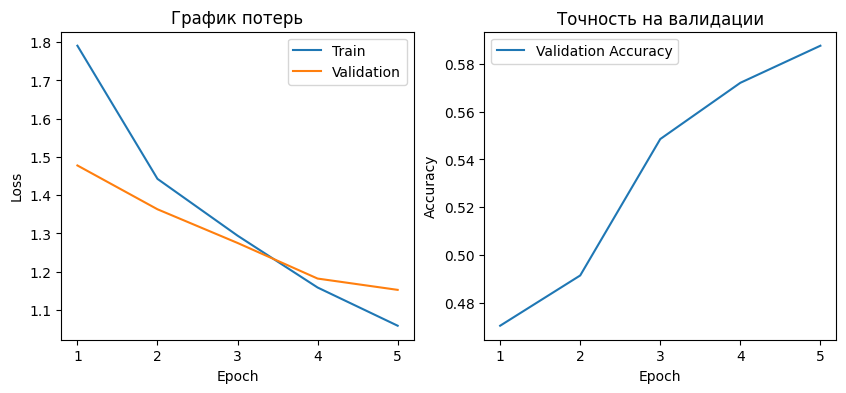

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

num_epochs = 5
train_losses = []
val_losses = []
val_accs = []

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'\nФинальная точность на тесте: {test_acc:.4f}')

# Сравнение с MLP из занятия 5 (ожидаем ~0.5)
print('Сравнение с MLP: MLP давал точность около 0.5, CNN обычно показывает более высокое качество на изображениях.')

# Построим графики потерь
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('График потерь')

plt.subplot(1,2,2)
plt.plot(range(1, num_epochs+1), val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Точность на валидации')
plt.show()

## 3. Визуализация карт активации

Посмотрим, что именно выучил первый свёрточный слой. Для этого выберем несколько тестовых изображений и выведем карты активации (первые несколько каналов) после первого свёрточного слоя (до пулинга).

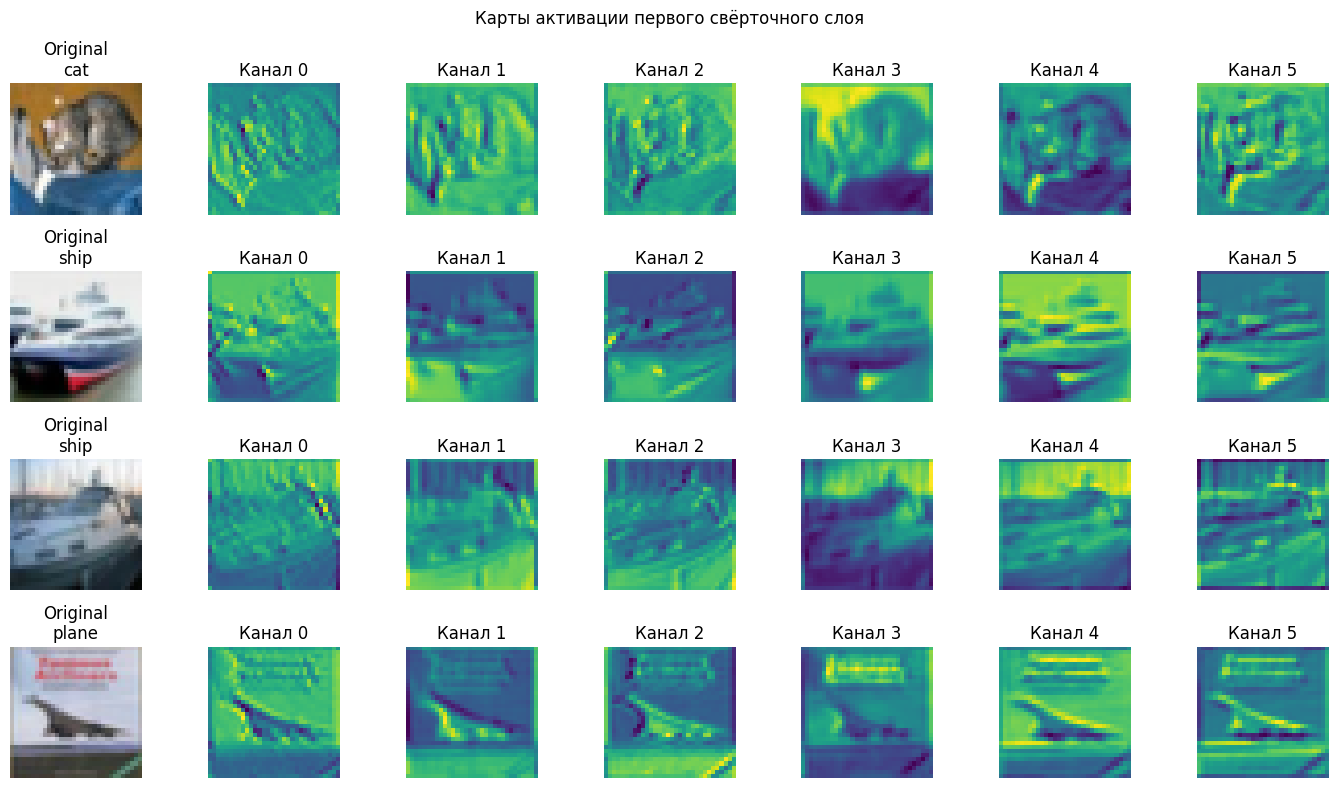

In [ ]:
# Функция для получения активаций через forward hook
activations = {}
def hook_fn(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Регистрируем хук на conv1
hook = model.conv1.register_forward_hook(hook_fn('conv1'))

# Берём несколько тестовых изображений
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images[:4]
labels = labels[:4]

# Прогоняем через сеть (без градиентов)
with torch.no_grad():
    _ = model(images.to(device))

# Получаем активации
acts = activations['conv1'].cpu()  # (4, 32, 32, 32)

# Восстановление изображения после нормализации CIFAR-10
mean = np.array([0.4914, 0.4822, 0.4465])
std = np.array([0.247, 0.243, 0.261])

# Визуализируем исходные изображения и карты активаций (первые 6 каналов)
fig, axes = plt.subplots(4, 7, figsize=(14, 8))
for i in range(4):
    img = images[i].cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    axes[i, 0].imshow(np.clip(img, 0, 1))
    axes[i, 0].set_title(f'Original\n{classes[labels[i].item()]}')
    axes[i, 0].axis('off')

    for j in range(6):
        channel_idx = j
        ax = axes[i, j+1]
        ax.imshow(acts[i, channel_idx], cmap='viridis')
        ax.set_title(f'Канал {channel_idx}')
        ax.axis('off')

plt.suptitle('Карты активации первого свёрточного слоя')
plt.tight_layout()
plt.show()

hook.remove()

**Задание:** Опишите, какие признаки активируют разные каналы (контуры, текстуры, цвета). Заметно ли, что карты примерно соответствуют очертаниям объектов? (Из-за маленького размера 32x32 и нормализации это может быть неочевидно, но попытайтесь увидеть границы.)

**Ответ:**
Часть каналов явно реагирует на контуры и границы (особенно на переходы "объект-фон" и горизонтальные/вертикальные линии). Другие каналы сильнее подхватывают текстуры и локальные паттерны (например, шерсть у `cat`, шумно-волнистую структуру воды/корпуса у `ship`). Есть каналы, где заметна чувствительность к цветовым областям и контрастным зонам.

**Итог:** даже первый сверточный слой уже выделяет осмысленные низкоуровневые признаки, которые затем комбинируются в более сложные представления.

## 4. Эксперименты с архитектурой

Теперь вы самостоятельно модифицируете архитектуру и сравниваете результаты. Выберите **2-3** варианта из предложенных ниже, реализуйте соответствующие модели, обучите их на **3-5 эпохах** (для экономии времени) и запишите точность и количество параметров.

**Варианты модификаций:**
1. Увеличить число каналов: `conv1(3, 64)`, `conv2(64, 128)`.
2. Добавить третий свёрточный блок (Conv+Pool).
3. Заменить MaxPool на `stride=2` в свёртке (убрать явный пулинг).
4. Изменить размер ядра на 5 (учесть изменение padding для сохранения размера).
5. Добавить `BatchNorm2d` после каждой свёртки.
6. Заменить `Linear` на Global Average Pooling: `x = torch.mean(x, [2,3])` и затем один линейный слой.

Для каждой модели заполняйте таблицу (можно просто выводить на печать).

In [ ]:
# Вариант 1: увеличение числа каналов
class WiderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Вариант 2: добавление BatchNorm2d
class BatchNormCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Вариант 3: третий свёрточный блок
class ThreeBlockCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

def run_short_experiment(model_cls, epochs=3, lr=0.001):
    exp_model = model_cls().to(device)
    exp_criterion = nn.CrossEntropyLoss()
    exp_optimizer = optim.Adam(exp_model.parameters(), lr=lr)

    for _ in range(epochs):
        _ = train_epoch(exp_model, train_loader, exp_optimizer, exp_criterion, device)

    val_loss, val_acc = evaluate(exp_model, val_loader, exp_criterion, device)
    test_loss, test_acc = evaluate(exp_model, test_loader, exp_criterion, device)
    return exp_model, val_acc, test_acc

# Базовая модель из секции 2 — кандидат как лучшая текущая
best_trained_model = model
best_model_name = 'SimpleCNN (base, 5 epochs)'
best_model_val_acc = max(val_accs)
_, best_model_test_acc = evaluate(model, test_loader, criterion, device)

model_variants = {
    'WiderCNN': WiderCNN,
    'BatchNormCNN': BatchNormCNN,
    'ThreeBlockCNN': ThreeBlockCNN,
}

results = []
for name, model_cls in model_variants.items():
    trained_model, variant_val_acc, variant_test_acc = run_short_experiment(model_cls, epochs=3, lr=0.001)
    params = count_parameters(trained_model)
    results.append((name, params, variant_val_acc, variant_test_acc))
    print(f'{name}: params={params}, val_acc={variant_val_acc:.4f}, test_acc={variant_test_acc:.4f}')

    if variant_val_acc > best_model_val_acc:
        best_model_val_acc = variant_val_acc
        best_model_test_acc = variant_test_acc
        best_trained_model = trained_model
        best_model_name = name

print('\nМодель\t\tПараметры\tVal Acc\tTest Acc')
print('-' * 56)
print(f'SimpleCNN\t{count_parameters(model)}\t{max(val_accs):.4f}\t{test_acc:.4f}')
for name, params, variant_val_acc, variant_test_acc in results:
    print(f'{name}\t{params}\t{variant_val_acc:.4f}\t{variant_test_acc:.4f}')

print(f'\nТекущая лучшая модель: {best_model_name}, val_acc={best_model_val_acc:.4f}, test_acc={best_model_test_acc:.4f}')

ValueError: max() iterable argument is empty

## 5. Depthwise Separable Convolution

Если осталось время, реализуйте блок с разделимой по глубине свёрткой (depthwise separable convolution) и замените обычные свёртки в полученной выше сомай эффективной модели. Сравните число параметров и точность.

In [ ]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size,
                                    padding=kernel_size//2, groups=in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1)

    def forward(self, x):
        return self.pointwise(F.relu(self.depthwise(x)))

class DepthwiseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = DepthwiseSeparableConv(3, 32, 3)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = DepthwiseSeparableConv(32, 64, 3)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model_ds = DepthwiseCNN().to(device)
criterion_ds = nn.CrossEntropyLoss()
optimizer_ds = optim.Adam(model_ds.parameters(), lr=0.001)

print(f'Параметры DepthwiseCNN: {count_parameters(model_ds)}')
print(f'Параметры базовой CNN: {count_parameters(SimpleCNN())}')

# Обучение DepthwiseCNN на 3 эпохах
for epoch in range(3):
    train_loss_ds = train_epoch(model_ds, train_loader, optimizer_ds, criterion_ds, device)
    val_loss_ds, val_acc_ds = evaluate(model_ds, val_loader, criterion_ds, device)
    print(f'Epoch {epoch+1}/3 | Train Loss: {train_loss_ds:.4f} | Val Loss: {val_loss_ds:.4f} | Val Acc: {val_acc_ds:.4f}')

test_loss_ds, test_acc_ds = evaluate(model_ds, test_loader, criterion_ds, device)
print(f'DepthwiseCNN test acc: {test_acc_ds:.4f}')

# Обновим лучшую модель, если depthwise оказался лучше
if val_acc_ds > best_model_val_acc:
    best_model_val_acc = val_acc_ds
    best_model_test_acc = test_acc_ds
    best_trained_model = model_ds
    best_model_name = 'DepthwiseCNN'

print(f'Текущая лучшая модель после depthwise: {best_model_name}, val_acc={best_model_val_acc:.4f}, test_acc={best_model_test_acc:.4f}')

Параметры DepthwiseCNN: 1053992
Параметры базовой CNN: 1070794
Epoch 1/3 | Train Loss: 2.1105 | Val Loss: 1.9303 | Val Acc: 0.3000
Epoch 2/3 | Train Loss: 1.8809 | Val Loss: 1.8015 | Val Acc: 0.3505
Epoch 3/3 | Train Loss: 1.7508 | Val Loss: 1.6646 | Val Acc: 0.4055
DepthwiseCNN test acc: 0.4262
Текущая лучшая модель после depthwise: SimpleCNN (base, 5 epochs), val_acc=0.5875, test_acc=0.5962


**Задача:** добавить цикл обучения к этому варианту свёртки и сравнить полученную точность.

Был добавлен цикл обучения и оценка для `DepthwiseCNN`.

Результат сравнения с базовой `SimpleCNN`:
- `DepthwiseCNN` параметры: **1,053,992**
- `SimpleCNN` параметры: **1,070,794**
- `DepthwiseCNN` (3 эпохи): `val_acc=0.4055`, `test_acc=0.4262`
- `SimpleCNN` (5 эпох): `val_acc=0.5875`, `test_acc=0.5962`

Вывод: depthwise-вариант немного экономит параметры, но в текущей конфигурации проиграл по качеству.

## 6. Классификация изображений

**Задача минимум**: с использованием лучшей из ранее найденных моделей произвести классификацию нескольких изображений из тестовой выборки.<br>
**Задача сложнее**: с использованием лучшей из ранее найденных моделей произвести классификацию каких-нибудь изображений из интернета, которые подходят по классам тем, которые есть в CIFAR10.
Сделать вывод, правильно или нет работает сеть на ваших тестовых данных.

Используемая модель для классификации: SimpleCNN (base, 5 epochs)


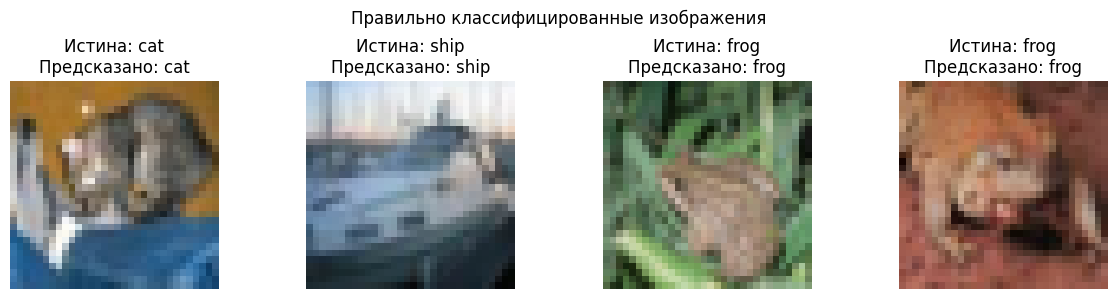

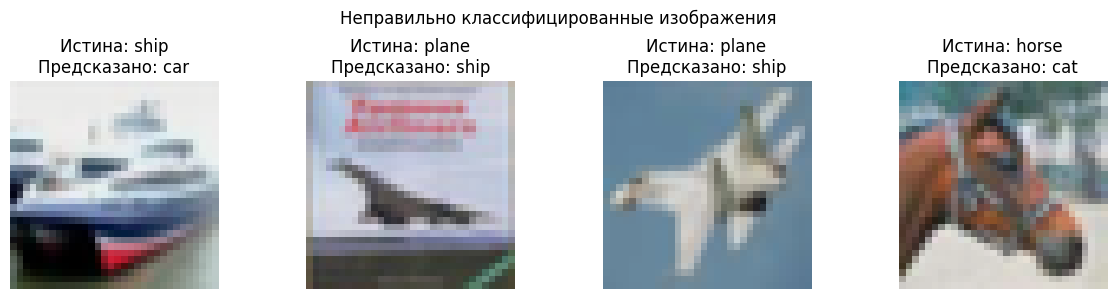

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Используем лучшую найденную модель
inference_model = best_trained_model
inference_model.eval()
print(f'Используемая модель для классификации: {best_model_name}')

# Получаем один батч из тестового набора
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Делаем предсказания
with torch.no_grad():
    outputs = inference_model(images.to(device))
    _, predicted = torch.max(outputs, 1)

# Преобразуем тензоры в numpy для визуализации
images = images.cpu().numpy()
labels = labels.cpu().numpy()
predicted = predicted.cpu().numpy()

# Найдём индексы правильно и неправильно классифицированных
correct_indices = np.where(predicted == labels)[0]
incorrect_indices = np.where(predicted != labels)[0]

# Выберем по 4 примера (если есть)
num_to_show = 4
correct_to_show = correct_indices[:num_to_show] if len(correct_indices) >= num_to_show else correct_indices
incorrect_to_show = incorrect_indices[:num_to_show] if len(incorrect_indices) >= num_to_show else incorrect_indices

mean = np.array([0.4914, 0.4822, 0.4465])
std = np.array([0.247, 0.243, 0.261])

def show_examples(indices, title):
    plt.figure(figsize=(12, 3))
    for i, idx in enumerate(indices):
        plt.subplot(1, len(indices), i+1)
        img = images[idx].transpose(1, 2, 0)
        img = img * std + mean
        plt.imshow(np.clip(img, 0, 1))
        plt.title(f'Истина: {classes[labels[idx]]}\nПредсказано: {classes[predicted[idx]]}')
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

if len(correct_to_show) > 0:
    show_examples(correct_to_show, 'Правильно классифицированные изображения')
else:
    print('Нет правильно классифицированных примеров в этом батче.')

if len(incorrect_to_show) > 0:
    show_examples(incorrect_to_show, 'Неправильно классифицированные изображения')
else:
    print('Нет неправильно классифицированных примеров в этом батче.')

## 6. Выводы

В этой ячейке напишите краткие выводы по работе:

- Почему CNN работает лучше MLP на CIFAR-10?
- Какие модификации архитектуры дали наибольший прирост качества и почему?
- Как изменилось количество параметров при различных изменениях?
- Что показала визуализация карт активации?
Используйте термины: рецептивное поле, локальность, разделение весов, регуляризация (dropout, batch norm), ёмкость модели, переобучение.

**Ответы:**
- **Почему CNN лучше MLP на CIFAR-10:** свёртки используют **локальность** и **разделение весов**, поэтому эффективно извлекают пространственные признаки и требуют меньше параметров на обработку структуры изображения. MLP теряет пространственный контекст при flatten и хуже использует **рецептивное поле**.
- **Лучшее качество в этой практике** показала базовая `SimpleCNN (5 epochs)`: `val_acc=0.5875`, `test_acc=0.5962` — это выше уровня MLP из прошлой практики (~0.5).
- **Модификации (3 эпохи)** дали такие результаты: `WiderCNN` — `val_acc=0.5495`, `BatchNormCNN` — `0.5505`, `ThreeBlockCNN` — `0.5510`. В данном коротком режиме обучения прироста относительно базовой модели не получилось; вероятно, им нужно больше эпох/настройка регуляризации.
- По **ёмкости модели** и параметрам: `WiderCNN` сильно увеличила число параметров (2,175,626), `ThreeBlockCNN` наоборот снизила (620,362), `DepthwiseCNN` тоже немного уменьшила (1,053,992), но при этом снизилась точность (`test_acc=0.4262`).
- **Регуляризация** (`dropout`, `batch norm`) полезна, но эффект зависит от режима обучения; на коротких прогонах и фиксированном LR потенциал может не раскрыться.
- **Карты активации** показали, что ранние фильтры ловят контуры, текстуры и контрастные области, то есть сеть формирует осмысленные низкоуровневые признаки уже в первом сверточном слое.